In [18]:
RUN_EMBEDDING = False

import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import PCA

import pandas as pd
import torch

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import hdbscan

from sentence_transformers import SentenceTransformer

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

DATA_DIR = "data"
MODELS_DIR = "models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RAW_DATA_PATH = os.path.join(DATA_DIR, "data_merged.csv")
EMBEDDINGS_PATH = os.path.join(DATA_DIR, "post_embeddings.npy")
DATA_WITH_EMBEDDINGS_PATH = os.path.join(DATA_DIR, "data_with_embeddings.csv")

In [19]:
if RUN_EMBEDDING:

    LOCAL_MODEL_PATH = os.path.join(
        MODELS_DIR,
        "paraphrase-multilingual-MiniLM-L12-v2"
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"

    print("Инициализация SentenceTransformer")
    print(f"Локальный путь к модели: {LOCAL_MODEL_PATH}")
    print(f"Устройство: {device}")

    if not os.path.exists(LOCAL_MODEL_PATH):
        raise FileNotFoundError(
            f"Локальная модель не найдена по пути: {LOCAL_MODEL_PATH}\n"
        )

    model = SentenceTransformer(
        LOCAL_MODEL_PATH,
        device=device
    )

    embedding_dim = model.get_embedding_dimension()

    print("Модель успешно загружена")
    print(f"Размерность эмбеддинга: {embedding_dim}")

    df_raw = pd.read_csv(RAW_DATA_PATH)

    required_columns = ["channel", "date", "message_id", "sender", "text"]
    missing_columns = [col for col in required_columns if col not in df_raw.columns]

    if missing_columns:
        raise ValueError(f"В датасете отсутствуют столбцы: {missing_columns}")

    print("\nСырые данные загружены")
    print(f"Количество строк: {len(df_raw)}")

    df_embeddings = df_raw[["channel", "date", "text"]].copy()

    df_embeddings["text"] = (
        df_embeddings["text"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    df_embeddings = df_embeddings[df_embeddings["text"] != ""].copy()
    df_embeddings = df_embeddings.reset_index(drop=True)

    print("\nПосле удаления пустых оригинальных текстов:")
    print(f"Количество строк: {len(df_embeddings)}")

    def clean_text_for_embedding(text):
        """Удаляет из текста ссылки и номера телефонов перед построением эмбеддингов."""

        text = str(text)

        # Удаление ссылок вида https://..., http://..., www....
        text = re.sub(
            r"https?://\S+|www\.\S+",
            " ",
            text
        )

        # Удаление Telegram-ссылок вида t.me/...
        text = re.sub(
            r"\bt\.me/\S+",
            " ",
            text
        )

        # Удаление номеров телефонов в разных форматах
        text = re.sub(
            r"(\+?\d[\d\s\-\(\)]{7,}\d)",
            " ",
            text
        )

        # Удаление лишних пробелов
        text = re.sub(
            r"\s+",
            " ",
            text
        ).strip()

        return text

    df_embeddings["text_for_embedding"] = (
        df_embeddings["text"]
        .apply(clean_text_for_embedding)
    )

    df_embeddings = df_embeddings[df_embeddings["text_for_embedding"] != ""].copy()
    df_embeddings = df_embeddings.reset_index(drop=True)

    texts = df_embeddings["text_for_embedding"].tolist()

    print("\nПосле очистки текстов для эмбеддингов:")
    print(f"Количество строк: {len(df_embeddings)}")

    print("\nПример оригинального и очищенного текста:")
    display(
        df_embeddings[["text", "text_for_embedding"]].head(3)
    )

    print("\nНачинается векторизация текстов")

    embeddings = model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("\nВекторизация завершена")
    print(f"Форма матрицы эмбеддингов: {embeddings.shape}")

    np.save(EMBEDDINGS_PATH, embeddings)

    df_embeddings["embedding"] = embeddings.tolist()

    df_embeddings.to_csv(
        DATA_WITH_EMBEDDINGS_PATH,
        index=False
    )

    print("\nРезультаты сохранены")
    print(f"Эмбеддинги сохранены в: {EMBEDDINGS_PATH}")
    print(f"Данные с эмбеддингами сохранены в: {DATA_WITH_EMBEDDINGS_PATH}")

else:
    print("Векторизация пропущена")
    print(f"Используются уже сохранённые эмбеддинги: {EMBEDDINGS_PATH}")

Векторизация пропущена
Используются уже сохранённые эмбеддинги: data\post_embeddings.npy


Данные для визуализации загружены
Форма матрицы эмбеддингов: (30688, 384)
Количество постов: 30688


C:\Users\Stepan\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Stepan\AppData\Roaming\Python\Python314\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


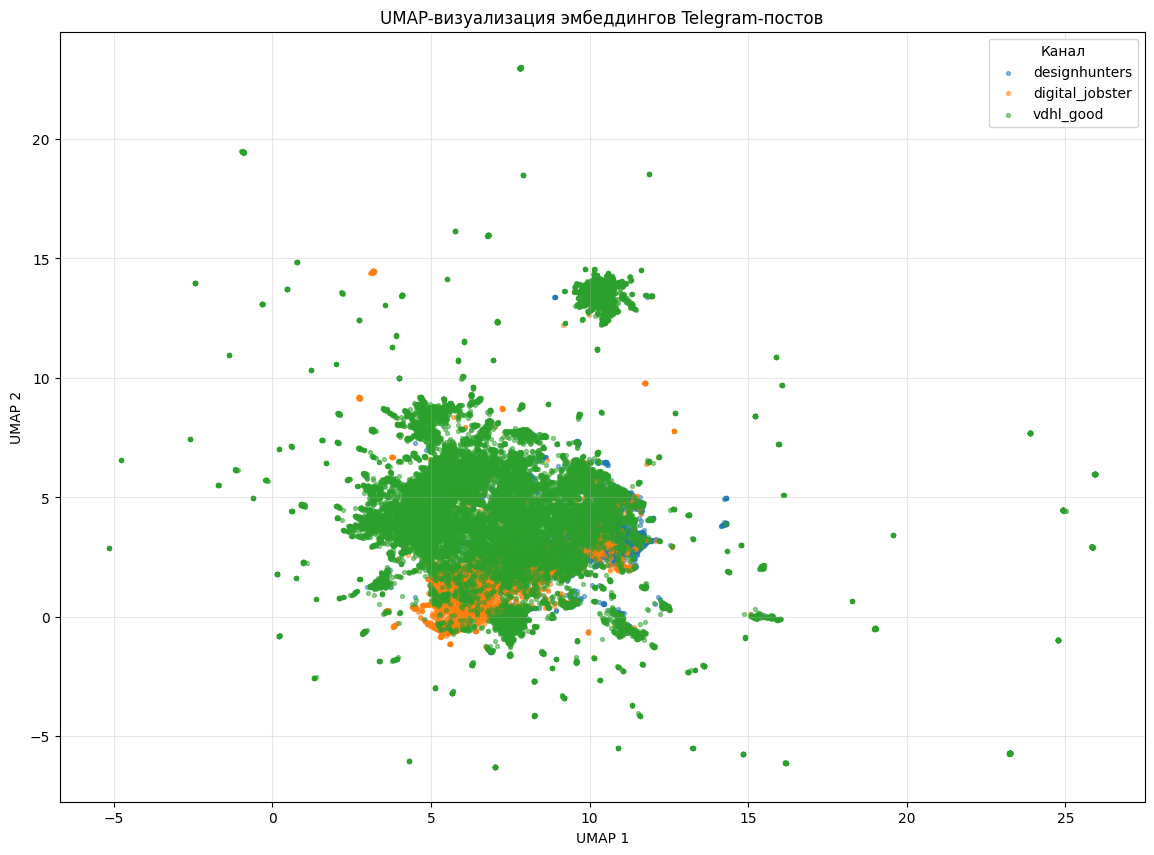

In [20]:
embeddings = np.load(EMBEDDINGS_PATH)

df_embeddings = pd.read_csv(
    DATA_WITH_EMBEDDINGS_PATH
)

print("Данные для визуализации загружены")
print(f"Форма матрицы эмбеддингов: {embeddings.shape}")
print(f"Количество постов: {len(df_embeddings)}")

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_2d = umap_model.fit_transform(
    embeddings
)

df_plot = df_embeddings[["channel", "date", "text"]].copy()

df_plot["x"] = embeddings_2d[:, 0]
df_plot["y"] = embeddings_2d[:, 1]

plt.figure(figsize=(14, 10))

for channel in sorted(df_plot["channel"].dropna().unique()):

    subset = df_plot[
        df_plot["channel"] == channel
    ]

    plt.scatter(
        subset["x"],
        subset["y"],
        s=8,
        alpha=0.5,
        label=channel
    )

plt.title(
    "UMAP-визуализация эмбеддингов Telegram-постов"
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend(title="Канал")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
embeddings_384 = np.load(EMBEDDINGS_PATH)

df_clustered = pd.read_csv(
    DATA_WITH_EMBEDDINGS_PATH
)

print("Данные загружены")
print(f"Форма эмбеддингов: {embeddings_384.shape}")
print(f"Количество строк в таблице: {len(df_clustered)}")

print("\nСнижение размерности через UMAP до 30 измерений")

umap_30_model = umap.UMAP(
    n_components=30,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    init="random",
    random_state=42
)

embeddings_30 = umap_30_model.fit_transform(
    embeddings_384
)

print(f"Форма после UMAP: {embeddings_30.shape}")

N_CLUSTERS = 20
MIN_CLUSTER_SIZE = 100
MIN_SAMPLES = 20

def evaluate_clustering(method_name, data_type, data, labels):
    labels = np.array(labels)

    total_count = len(labels)
    noise_count = np.sum(labels == -1)
    noise_share = noise_count / total_count * 100

    cluster_labels = labels[labels != -1]
    unique_clusters = sorted(set(cluster_labels))

    n_clusters = len(unique_clusters)

    if n_clusters > 0:
        cluster_sizes = pd.Series(cluster_labels).value_counts()
        largest_cluster_share = cluster_sizes.max() / total_count * 100
        small_clusters_count = (cluster_sizes < 10).sum()
    else:
        largest_cluster_share = np.nan
        small_clusters_count = np.nan

    metrics_data = data[labels != -1]
    metrics_labels = labels[labels != -1]

    if len(set(metrics_labels)) >= 2 and len(metrics_labels) > len(set(metrics_labels)):
        silhouette = silhouette_score(
            metrics_data,
            metrics_labels,
            metric="euclidean",
            sample_size=min(3000, len(metrics_labels)),
            random_state=42
        )

        davies_bouldin = davies_bouldin_score(
            metrics_data,
            metrics_labels
        )

        calinski_harabasz = calinski_harabasz_score(
            metrics_data,
            metrics_labels
        )
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    return {
        "method": method_name,
        "data": data_type,
        "n_clusters": n_clusters,
        "noise_share_%": round(noise_share, 2),
        "largest_cluster_share_%": round(largest_cluster_share, 2),
        "small_clusters_count": small_clusters_count,
        "silhouette": round(silhouette, 4) if not np.isnan(silhouette) else np.nan,
        "davies_bouldin": round(davies_bouldin, 4) if not np.isnan(davies_bouldin) else np.nan,
        "calinski_harabasz": round(calinski_harabasz, 2) if not np.isnan(calinski_harabasz) else np.nan
    }

clustering_results = []
metrics_results = []


# 1. K-Means на 384 измерениях

# print("\nK-Means на 384 измерениях")

# kmeans_384 = KMeans(
#     n_clusters=N_CLUSTERS,
#     random_state=42,
#     n_init=10
# )

# labels_kmeans_384 = kmeans_384.fit_predict(
#     embeddings_384
# )

# df_clustered["cluster_kmeans_384"] = labels_kmeans_384

# metrics_results.append(
#     evaluate_clustering(
#         "K-Means",
#         "384 dimensions",
#         embeddings_384,
#         labels_kmeans_384
#     )
# )


# 2. Agglomerative Clustering на 384 измерениях

# print("Agglomerative Clustering на 384 измерениях")

# agglomerative_384 = AgglomerativeClustering(
#     n_clusters=N_CLUSTERS,
#     metric="cosine",
#     linkage="average"
# )

# labels_agglomerative_384 = agglomerative_384.fit_predict(
#     embeddings_384
# )

# df_clustered["cluster_agglomerative_384"] = labels_agglomerative_384

# metrics_results.append(
#     evaluate_clustering(
#         "Agglomerative",
#         "384 dimensions",
#         embeddings_384,
#         labels_agglomerative_384
#     )
# )


# 3. HDBSCAN на 384 измерениях

# print("HDBSCAN на 384 измерениях")

# hdbscan_384 = hdbscan.HDBSCAN(
#     min_cluster_size=MIN_CLUSTER_SIZE,
#     min_samples=MIN_SAMPLES,
#     metric="euclidean"
# )

# labels_hdbscan_384 = hdbscan_384.fit_predict(
#     embeddings_384
# )

# df_clustered["cluster_hdbscan_384"] = labels_hdbscan_384

# metrics_results.append(
#     evaluate_clustering(
#         "HDBSCAN",
#         "384 dimensions",
#         embeddings_384,
#         labels_hdbscan_384
#     )
# )


# 4. K-Means на 30 измерениях после UMAP

print("K-Means на 30 измерениях после UMAP")

kmeans_30 = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

labels_kmeans_30 = kmeans_30.fit_predict(
    embeddings_30
)

df_clustered["cluster_kmeans_umap_30"] = labels_kmeans_30

metrics_results.append(
    evaluate_clustering(
        "K-Means",
        "UMAP 30 dimensions",
        embeddings_30,
        labels_kmeans_30
    )
)


# 5. Agglomerative Clustering на 30 измерениях после UMAP

print("Agglomerative Clustering на 30 измерениях после UMAP")

agglomerative_30 = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric="euclidean",
    linkage="ward"
)

labels_agglomerative_30 = agglomerative_30.fit_predict(
    embeddings_30
)

df_clustered["cluster_agglomerative_umap_30"] = labels_agglomerative_30

metrics_results.append(
    evaluate_clustering(
        "Agglomerative",
        "UMAP 30 dimensions",
        embeddings_30,
        labels_agglomerative_30
    )
)


# 6. HDBSCAN на 30 измерениях после UMAP

print("HDBSCAN на 30 измерениях после UMAP")

hdbscan_30 = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

labels_hdbscan_30 = hdbscan_30.fit_predict(
    embeddings_30
)

df_clustered["cluster_hdbscan_umap_30"] = labels_hdbscan_30

metrics_results.append(
    evaluate_clustering(
        "HDBSCAN",
        "UMAP 30 dimensions",
        embeddings_30,
        labels_hdbscan_30
    )
)

df_metrics = pd.DataFrame(metrics_results)

print("\nСравнение методов кластеризации")
display(df_metrics)

cluster_columns = [
    "cluster_kmeans_384",
    "cluster_agglomerative_384",
    "cluster_hdbscan_384",
    "cluster_kmeans_umap_30",
    "cluster_agglomerative_umap_30",
    "cluster_hdbscan_umap_30"
]

for column in cluster_columns:
    print(f"\nРаспределение размеров кластеров: {column}")

    cluster_distribution = (
        df_clustered[column]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    cluster_distribution.columns = ["cluster", "count"]

    display(cluster_distribution)

Данные загружены
Форма эмбеддингов: (30688, 384)
Количество строк в таблице: 30688

Снижение размерности через UMAP до 30 измерений


C:\Users\Stepan\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Форма после UMAP: (30688, 30)

K-Means на 384 измерениях
Agglomerative Clustering на 384 измерениях
HDBSCAN на 384 измерениях
K-Means на 30 измерениях после UMAP
Agglomerative Clustering на 30 измерениях после UMAP
HDBSCAN на 30 измерениях после UMAP

Сравнение методов кластеризации


,method,data,n_clusters,noise_share_%,largest_cluster_share_%,small_clusters_count,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,384 dimensions,20,0.00,7.25,0,0.0486,3.3396,545.45
1,Agglomerative,384 dimensions,20,0.00,94.21,13,0.0544,1.8572,61.03
2,HDBSCAN,384 dimensions,3,85.09,12.16,0,0.1766,1.4343,565.52
3,K-Means,UMAP 30 dimensions,20,0.00,15.63,0,0.3125,0.7042,7856.38
4,Agglomerative,UMAP 30 dimensions,20,0.00,17.35,0,0.2922,0.7367,7128.89
5,HDBSCAN,UMAP 30 dimensions,4,2.76,91.05,0,0.5502,0.3303,9568.88



Распределение размеров кластеров: cluster_kmeans_384


...

,cluster,count
0,0,4204
1,1,1605
2,2,1928
3,3,3166
4,4,1571
5,5,111
6,6,60
7,7,4797
8,8,1926
9,9,66



Распределение размеров кластеров: cluster_agglomerative_umap_30


,cluster,count
0,0,4221
1,1,3298
2,2,5040
3,3,5324
4,4,1932
5,5,760
6,6,4197
7,7,1451
8,8,2132
9,9,34



Распределение размеров кластеров: cluster_hdbscan_umap_30


,cluster,count
0,-1,846
1,0,111
2,1,1593
3,2,197
4,3,27941


Данные загружены
Количество постов: 30688
Снижение размерности через UMAP


C:\Users\Stepan\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Форма после UMAP: (30688, 30)
Запуск HDBSCAN
Кластеризация завершена


,cluster,count
0,-1,846
1,0,111
2,1,1593
3,2,197
4,3,27941


Результаты сохранены в data\data_with_embeddings.csv
Подготовка визуализации


C:\Users\Stepan\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


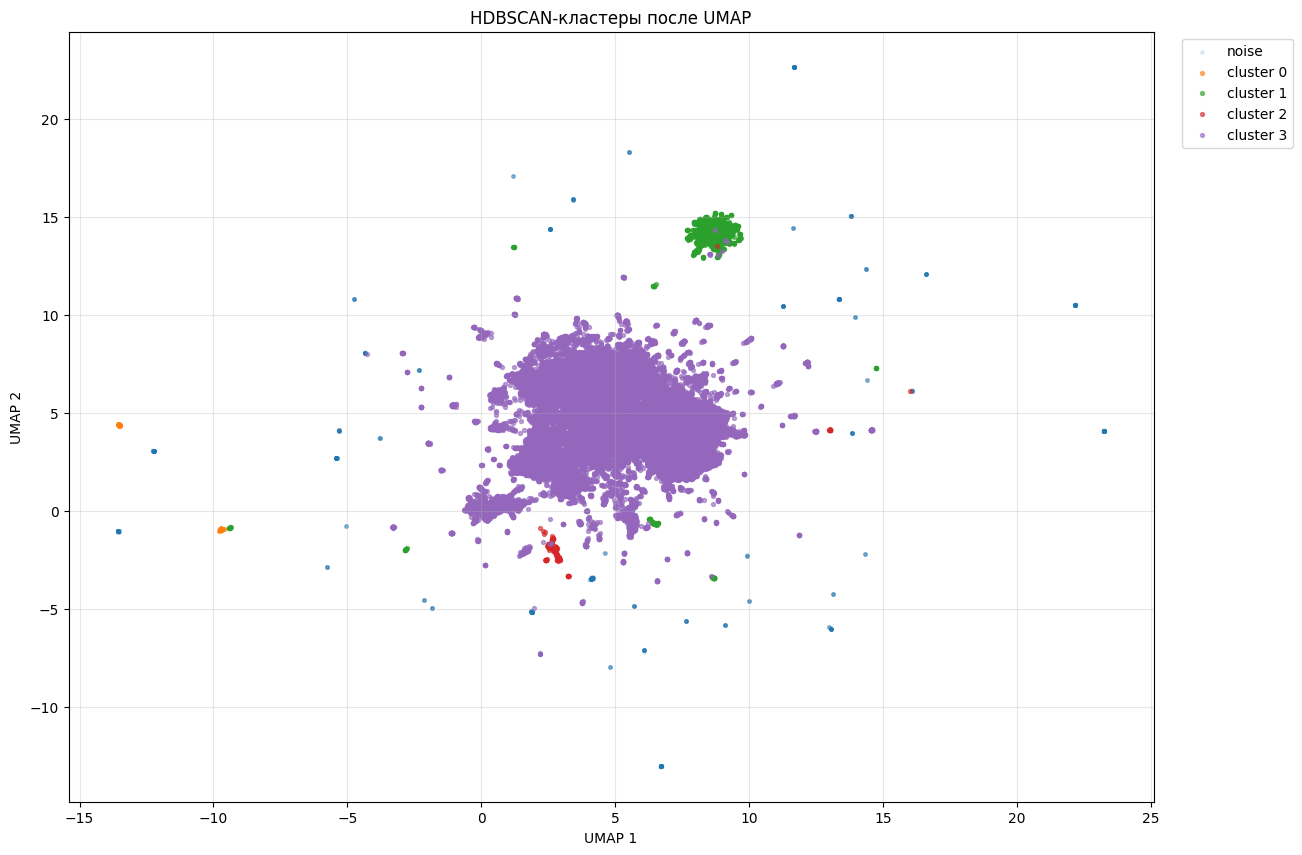

Поиск характерных слов кластеров
Сводка по кластерам


,cluster,size,top_words
3,3,27941,"контакты, умение, работать, условия, требования, сайте, менеджер"
1,1,1593,"цитата_дня_vdhl, жизнь, жизни, всё, просто, делать, время"
2,2,197,"животных, животным, фонда, собак, собаки, гуляки, собаки гуляки"
0,0,111,"цитата дня, цитата, дня"


Примеры постов по кластерам

КЛАСТЕР 0
Размер: 111
Топ слова: цитата дня, цитата, дня

Пример 1
ЦИТАТА ДНЯ

Пример 2
ЦИТАТА ДНЯ

Пример 3
ЦИТАТА ДНЯ

Пример 4
ЦИТАТА ДНЯ

Пример 5
ЦИТАТА ДНЯ

КЛАСТЕР 1
Размер: 1593
Топ слова: цитата_дня_vdhl, жизнь, жизни, всё, просто, делать, время

Пример 1
#ЦИТАТА_ДНЯ_VDHL

"Практически в любой проблемной области жизни вы сами являетесь и проблемой, и ее решением". Джон Кехо.

Пример 2
#ЦИТАТА_ДНЯ_VDHL

Наши враги дают нам прекрасную возможность практиковать терпение, стойкость и сострадание. Далай-Лама

Пример 3
#ЦИТАТА_ДНЯ_VDHL

«Не стоит ждать, пока наступит счастье, лучше наступи в него сам».

Пример 4
#ЦИТАТА_ДНЯ_VDHL

"Назидательный тон - то, на что у большинства из нас жуткая аллергия со времён школы. Не будьте аллергеном!" Нина Зверева.

Пример 5
[Почему критика — не боль, а инструмент](https://dsgners.ru/nixnix/17521-pochemu-kritika-ne-bol-a-instrument)

Статья раскрывает, почему критика может быть болезненной и как изменить свое отношение 

In [ ]:
embeddings_384 = np.load(EMBEDDINGS_PATH)

df_clusters = pd.read_csv(
    DATA_WITH_EMBEDDINGS_PATH
)

print("Данные загружены")
print(f"Количество постов: {len(df_clusters)}")

russian_stop_words = [
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще",
    "нет", "о", "из", "ему", "теперь", "когда", "даже", "ну", "вдруг",
    "ли", "если", "уже", "или", "ни", "быть", "был", "него", "до", "вас",
    "нибудь", "опять", "уж", "вам", "ведь", "там", "потом", "себя", "ничего",
    "ей", "может", "они", "тут", "где", "есть", "надо", "ней", "для", "мы",
    "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего",
    "раз", "тоже", "себе", "под", "будет", "ж", "тогда", "кто", "этот",
    "того", "потому", "этого", "какой", "совсем", "ним", "здесь", "этом",
    "один", "почти", "мой", "тем", "чтобы", "нее", "сейчас", "были", "куда",
    "зачем", "всех", "никогда", "можно", "при", "наконец", "два", "об",
    "другой", "хоть", "после", "над", "больше", "тот", "через", "эти", "нас",
    "про", "всего", "них", "какая", "много", "разве", "три", "эту", "моя",
    "впрочем", "хорошо", "свою", "этой", "перед", "иногда", "лучше", "чуть",
    "том", "нельзя", "такой", "им", "более", "всегда", "конечно", "всю",
    "между", "это", "также", "которые", "который", "которая", "которое",
    "которых", "которым", "которыми"
]

english_stop_words = [
    "the", "a", "an", "and", "or", "but", "if", "then", "else", "when",
    "at", "by", "for", "with", "about", "against", "between", "into",
    "through", "during", "before", "after", "above", "below", "to", "from",
    "up", "down", "in", "out", "on", "off", "over", "under", "again",
    "further", "than", "once", "here", "there", "all", "any", "both",
    "each", "few", "more", "most", "other", "some", "such", "no", "nor",
    "not", "only", "own", "same", "so", "too", "very", "can", "will",
    "just", "don", "should", "now", "is", "are", "was", "were", "be",
    "been", "being", "have", "has", "had", "do", "does", "did", "this",
    "that", "these", "those", "we", "you", "he", "she", "it", "they",
    "them", "his", "her", "their", "our", "your"
]

project_stop_words = [
    "ru", "com", "https", "http", "www", "tme", "telegram", "tg",
    "работа", "работы", "работу", "вакансия", "вакансии", "вакансию",
    "ищем", "ищет", "нужен", "нужна", "нужно", "требуется",
    "команда", "команду", "команде", "опыт", "опыта",
    "отклик", "откликнуться", "резюме", "портфолио",
    "подробнее", "ссылка", "писать", "пишите"
]

stop_words = russian_stop_words + english_stop_words + project_stop_words

print("Снижение размерности через UMAP")

umap_30 = umap.UMAP(
    n_components=30,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    init="random",
    random_state=42
)

embeddings_30 = umap_30.fit_transform(
    embeddings_384
)

print(f"Форма после UMAP: {embeddings_30.shape}")

print("Запуск HDBSCAN")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    metric="euclidean"
)

labels = clusterer.fit_predict(
    embeddings_30
)

df_clusters["cluster"] = labels

print("Кластеризация завершена")

display(
    df_clusters["cluster"]
    .value_counts()
    .sort_index()
    .rename("count")
    .reset_index()
)

df_clusters.to_csv(
    DATA_WITH_EMBEDDINGS_PATH,
    index=False
)

print(f"Результаты сохранены в {DATA_WITH_EMBEDDINGS_PATH}")

print("Подготовка визуализации")

umap_2 = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    init="random",
    random_state=42
)

embeddings_2d = umap_2.fit_transform(
    embeddings_384
)

df_clusters["x"] = embeddings_2d[:, 0]
df_clusters["y"] = embeddings_2d[:, 1]

plt.figure(figsize=(14, 10))

unique_clusters = sorted(
    df_clusters["cluster"].unique()
)

for cluster_id in unique_clusters:

    subset = df_clusters[
        df_clusters["cluster"] == cluster_id
    ]

    if cluster_id == -1:
        plt.scatter(
            subset["x"],
            subset["y"],
            s=6,
            alpha=0.12,
            label="noise"
        )
    else:
        plt.scatter(
            subset["x"],
            subset["y"],
            s=8,
            alpha=0.6,
            label=f"cluster {cluster_id}"
        )

plt.title("HDBSCAN-кластеры после UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.show()

def prepare_text_for_tfidf(text):
    text = str(text).lower()

    text = re.sub(
        r"https?://\S+|www\.\S+|\bt\.me/\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zа-яё0-9_#+\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df_clusters["text_for_tfidf"] = (
    df_clusters["text"]
    .fillna("")
    .astype(str)
    .apply(prepare_text_for_tfidf)
)

print("Поиск характерных слов кластеров")

cluster_ids = sorted(
    [
        cluster_id
        for cluster_id in df_clusters["cluster"].unique()
        if cluster_id != -1
    ]
)

cluster_summary = []

for cluster_id in cluster_ids:

    cluster_texts = (
        df_clusters.loc[
            df_clusters["cluster"] == cluster_id,
            "text_for_tfidf"
        ]
        .fillna("")
        .astype(str)
    )

    if len(cluster_texts) < 10:
        continue

    vectorizer = TfidfVectorizer(
        stop_words=stop_words,
        max_features=5000,
        ngram_range=(1, 2),
        min_df=3,
        token_pattern=r"(?u)\b[а-яёa-z][а-яёa-z0-9_+#]{2,}\b"
    )

    tfidf_matrix = vectorizer.fit_transform(
        cluster_texts
    )

    scores = np.asarray(
        tfidf_matrix.mean(axis=0)
    ).ravel()

    feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    top_indices = scores.argsort()[::-1][:10]
    top_words = feature_names[top_indices]

    cluster_summary.append({
        "cluster": cluster_id,
        "size": len(cluster_texts),
        "top_words": ", ".join(top_words[:7])
    })

summary_df = pd.DataFrame(
    cluster_summary
)

print("Сводка по кластерам")

display(
    summary_df.sort_values(
        "size",
        ascending=False
    )
)

print("Примеры постов по кластерам")

for cluster_id in cluster_ids:

    subset = df_clusters[
        df_clusters["cluster"] == cluster_id
    ]

    print("\n" + "=" * 80)
    print(f"КЛАСТЕР {cluster_id}")
    print(f"Размер: {len(subset)}")

    cluster_info = summary_df[
        summary_df["cluster"] == cluster_id
    ]

    if len(cluster_info):
        print(
            "Топ слова: "
            + cluster_info.iloc[0]["top_words"]
        )

    sample_posts = (
        subset["text"]
        .sample(
            min(5, len(subset)),
            random_state=42
        )
        .tolist()
    )

    for i, post in enumerate(sample_posts, start=1):
        print(f"\nПример {i}")
        print(str(post)[:1000])

In [25]:
df_diagnostics = pd.read_csv(DATA_WITH_EMBEDDINGS_PATH)

required_columns = ["text", "cluster"]

missing_columns = [
    column
    for column in required_columns
    if column not in df_diagnostics.columns
]

if missing_columns:
    raise ValueError(
        f"В файле отсутствуют столбцы: {missing_columns}"
    )

df_diagnostics["text"] = (
    df_diagnostics["text"]
    .fillna("")
    .astype(str)
)

print("Данные для диагностики загружены")
print(f"Количество постов: {len(df_diagnostics)}")

advertising_patterns = [
    r"\bкурс\w*\b",
    r"\bобучени\w*\b",
    r"\bвебинар\w*\b",
    r"\bинтенсив\w*\b",
    r"\bмастер[- ]?класс\w*\b",
    r"\bлекци\w*\b",
    r"\bмарафон\w*\b",
    r"\bтариф\w*\b",
    r"\bпромокод\w*\b",
    r"\bскидк\w*\b",
    r"\bраспродаж\w*\b",
    r"\bкупить\w*\b",
    r"\bпокупк\w*\b",
    r"\bзапис\w*\b",
    r"\bрегистрац\w*\b",
    r"\bстарт\w*\b",
    r"\bместа ограничены\b",
    r"\bбесплатн\w*\b",
    r"\bплатн\w*\b",
    r"\bв продаже\b",
    r"\bоткрыт набор\b",
    r"\bнабор открыт\b",
    r"\bприобрест\w*\b",
    r"\bподписк\w*\b",
    r"\bрозыгрыш\w*\b",
    r"\bконкурс\w*\b"
]

advertising_regex = "|".join(advertising_patterns)

df_diagnostics["is_advertising_candidate"] = (
    df_diagnostics["text"]
    .str.lower()
    .str.contains(
        advertising_regex,
        regex=True,
        na=False
    )
)

quote_patterns = [
    r"#цитата",
    r"#цитата_дня",
    r"цитата дня",
    r"цитата_дня",
    r"мысль дня",
    r"мудрость дня"
]

quote_regex = "|".join(quote_patterns)

df_diagnostics["is_quote_candidate"] = (
    df_diagnostics["text"]
    .str.lower()
    .str.contains(
        quote_regex,
        regex=True,
        na=False
    )
)

advertising_count = df_diagnostics[
    "is_advertising_candidate"
].sum()

quote_count = df_diagnostics[
    "is_quote_candidate"
].sum()

print("\nОбщая статистика")
print(f"Постов с рекламными маркерами: {advertising_count}")
print(f"Постов с маркерами цитат: {quote_count}")

advertising_distribution = (
    df_diagnostics[
        df_diagnostics["is_advertising_candidate"]
    ]
    .groupby("cluster")
    .size()
    .reset_index(name="advertising_posts")
)

cluster_sizes = (
    df_diagnostics
    .groupby("cluster")
    .size()
    .reset_index(name="cluster_size")
)

advertising_distribution = (
    cluster_sizes
    .merge(
        advertising_distribution,
        on="cluster",
        how="left"
    )
)

advertising_distribution["advertising_posts"] = (
    advertising_distribution["advertising_posts"]
    .fillna(0)
    .astype(int)
)

advertising_distribution["advertising_share_%"] = (
    advertising_distribution["advertising_posts"]
    / advertising_distribution["cluster_size"]
    * 100
).round(2)

advertising_distribution = (
    advertising_distribution
    .sort_values(
        ["advertising_share_%", "advertising_posts"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nРаспределение рекламных кандидатов по кластерам")
display(advertising_distribution)

quote_distribution = (
    df_diagnostics[
        df_diagnostics["is_quote_candidate"]
    ]
    .groupby("cluster")
    .size()
    .reset_index(name="quote_posts")
)

quote_distribution = (
    cluster_sizes
    .merge(
        quote_distribution,
        on="cluster",
        how="left"
    )
)

quote_distribution["quote_posts"] = (
    quote_distribution["quote_posts"]
    .fillna(0)
    .astype(int)
)

quote_distribution["quote_share_%"] = (
    quote_distribution["quote_posts"]
    / quote_distribution["cluster_size"]
    * 100
).round(2)

quote_distribution = (
    quote_distribution
    .sort_values(
        ["quote_share_%", "quote_posts"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nРаспределение цитат по кластерам")
display(quote_distribution)

clusters_with_advertising = (
    advertising_distribution[
        advertising_distribution["advertising_posts"] > 0
    ]["cluster"]
    .tolist()
)

print("\nПримеры постов с рекламными маркерами")

for cluster_id in clusters_with_advertising:

    subset = df_diagnostics[
        (df_diagnostics["cluster"] == cluster_id)
        & (df_diagnostics["is_advertising_candidate"])
    ]

    print("\n" + "=" * 80)

    if cluster_id == -1:
        print("ВЫБРОСЫ (-1)")
    else:
        print(f"КЛАСТЕР {cluster_id}")

    print(f"Количество рекламных кандидатов: {len(subset)}")

    sample_posts = subset["text"].sample(
        min(5, len(subset)),
        random_state=42
    )

    for number, post in enumerate(sample_posts, start=1):
        print(f"\nПример {number}")
        print(post[:1200])

clusters_with_quotes = (
    quote_distribution[
        quote_distribution["quote_posts"] > 0
    ]["cluster"]
    .tolist()
)

print("\nПримеры постов с маркерами цитат")

for cluster_id in clusters_with_quotes:

    subset = df_diagnostics[
        (df_diagnostics["cluster"] == cluster_id)
        & (df_diagnostics["is_quote_candidate"])
    ]

    print("\n" + "=" * 80)

    if cluster_id == -1:
        print("ВЫБРОСЫ (-1)")
    else:
        print(f"КЛАСТЕР {cluster_id}")

    print(f"Количество цитат: {len(subset)}")

    sample_posts = subset["text"].sample(
        min(5, len(subset)),
        random_state=42
    )

    for number, post in enumerate(sample_posts, start=1):
        print(f"\nПример {number}")
        print(post[:1200])

Данные для диагностики загружены
Количество постов: 30688

Общая статистика
Постов с рекламными маркерами: 8917
Постов с маркерами цитат: 1973

Распределение рекламных кандидатов по кластерам


,cluster,cluster_size,advertising_posts,advertising_share_%
0,3,27941,8676,31.05
1,2,197,54,27.41
2,-1,846,172,20.33
3,1,1593,15,0.94
4,0,111,0,0.00



Распределение цитат по кластерам


,cluster,cluster_size,quote_posts,quote_share_%
0,0,111,107,96.40
1,1,1593,1512,94.92
2,-1,846,330,39.01
3,2,197,1,0.51
4,3,27941,23,0.08



Примеры постов с рекламными маркерами

КЛАСТЕР 3
Количество рекламных кандидатов: 8676

Пример 1
**МЕНЕДЖЕР ПО РАБОТЕ СО СТУДЕНТАМИ в команду Софт Культуры (удалёнка).**

Мы — образовательная площадка для архитекторов, дизайнеров интерьера и урбанистов. В нашей команде ребята-единомышленники делают классный обучающий продукт, а отдел поддержки делает всё, чтобы студенты чувствовали себя окруженными заботой и ни о чём не переживали 😎

Нам нужен человек, который будет менеджерить курсы и рабочие процессы, а также общаться с теми, кто учится у нас или только думает начать.

**Что надо будет делать:**
— Консультировать потенциальных студентов по выбору курса, помогать им определяться с выбором;
— Отвечать на вопросы наших студентов;
— Обрабатывать входящие заявки, периодически возвращаться к тем, кто планировал присоединиться к курсам;
— Работать с внутренней базой курсов и AmoCRM, командным таск-трекером и не только;
— Работать с платёжными системами и 1С;
— Сопровождать курсы: распредел